<a href="https://colab.research.google.com/github/EktaSinghES/Machine_Learning_Lab-2547221/blob/LAB_ACTIVITY/Decision_Tree_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Classification on the Iris Dataset

This notebook demonstrates how to:

- Load and understand the Iris dataset
- Visualise the dataset
- Train a Decision Tree Classifier
- Display the complete decision tree
- Evaluate the model
- Analyse feature importance
- Visualise decision boundaries using two features


## 1. Import the Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## 2. Load the Iris Dataset

The Iris dataset contains **150 flower samples** belonging to three species:

- Iris Setosa
- Iris Versicolor
- Iris Virginica

Each flower has four input features:

- Sepal length
- Sepal width
- Petal length
- Petal width


In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

print('Feature names:', iris.feature_names)
print('Target names:', iris.target_names)
print('Dataset shape:', X.shape)


Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Dataset shape: (150, 4)


## 3. Represent the Dataset as a DataFrame

In [ ]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = df['target'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
print('Class distribution:')
print(df['species'].value_counts())

print('\nDataset information:')
df.info()


Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## 4. Visual Representation of the Iris Dataset

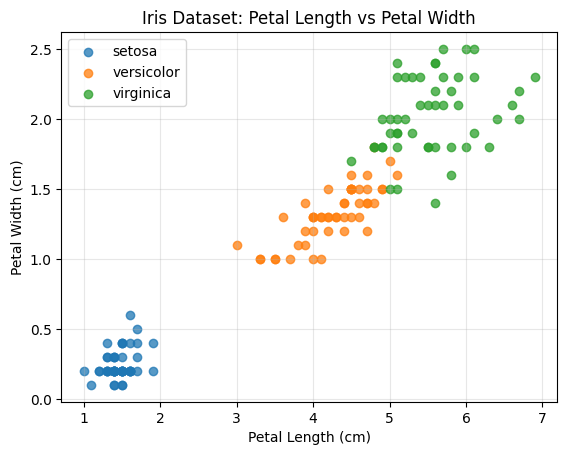

In [ ]:
for species_name in iris.target_names:
    subset = df[df['species'] == species_name]
    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=species_name,
        alpha=0.75
    )

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Dataset: Petal Length vs Petal Width')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 5. Split the Dataset into Training and Testing Sets

We use 80% of the data for training and 20% for testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])


Training samples: 120
Testing samples: 30


## 6. Create and Train the Decision Tree

The tree uses **Gini impurity** to determine the best feature and threshold for each split.

In [ ]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print('Decision tree trained successfully.')


Decision tree trained successfully.


## 7. Visual Representation of the Decision Tree

Each decision node shows:

- Splitting condition
- Gini impurity
- Number of samples
- Number of samples in each class
- Predicted class

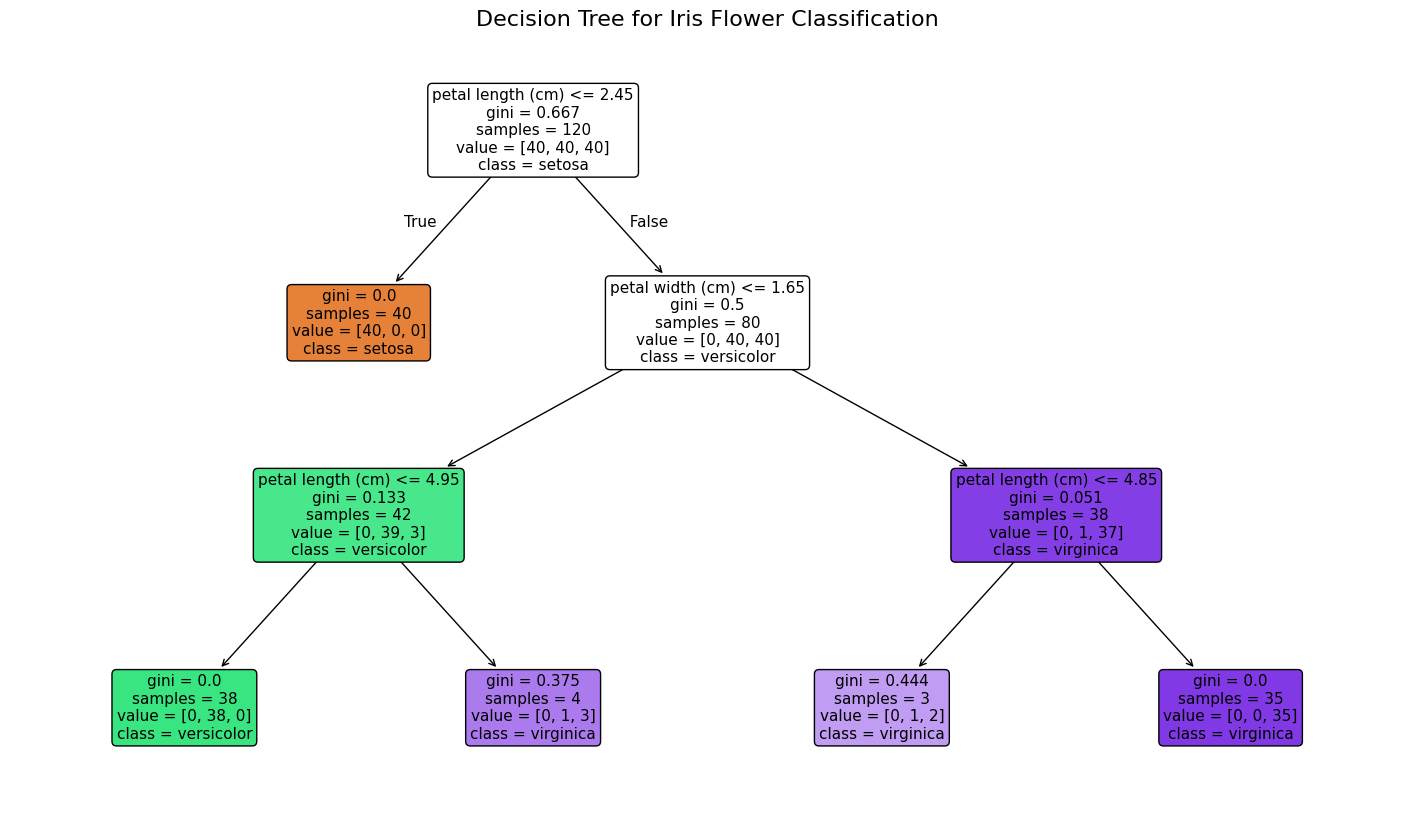

In [ ]:
plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=11
)

plt.title('Decision Tree for Iris Flower Classification', fontsize=16)
plt.show()


## 8. Display the Decision Rules in Text Form

In [ ]:
tree_rules = export_text(model, feature_names=list(iris.feature_names))
print(tree_rules)


|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



## 9. Make Predictions

In [ ]:
y_pred = model.predict(X_test)

prediction_table = pd.DataFrame({
    'Actual Class': [iris.target_names[i] for i in y_test],
    'Predicted Class': [iris.target_names[i] for i in y_pred]
})

prediction_table.head(10)

,Actual Class,Predicted Class
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


## 10. Evaluate the Decision Tree

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 11. Confusion Matrix

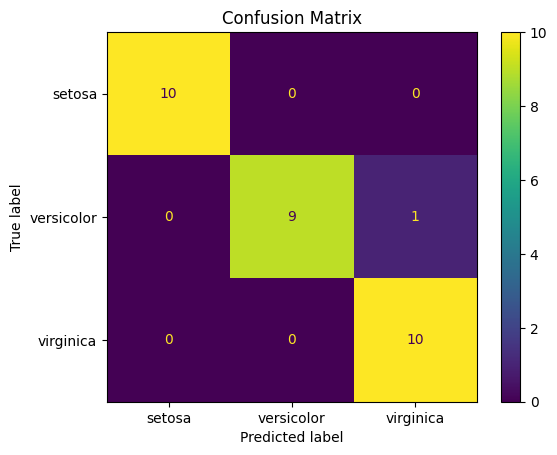

In [ ]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot()
plt.title('Confusion Matrix')
plt.show()


## 12. Feature Importance

Feature importance indicates how useful each feature was in creating the decision tree.

In [ ]:
importance_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
2,petal length (cm),0.579077
3,petal width (cm),0.420923
1,sepal width (cm),0.000000
0,sepal length (cm),0.000000


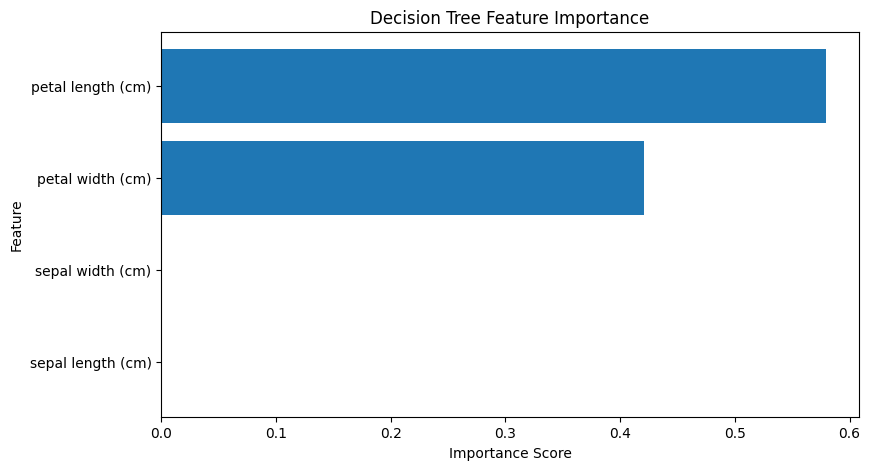

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Decision Tree Feature Importance')
plt.gca().invert_yaxis()
plt.show()


## 13. Predict a New Iris Flower

In [ ]:
# Input order:
# sepal length, sepal width, petal length, petal width
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

predicted_class = model.predict(new_flower)[0]
predicted_species = iris.target_names[predicted_class]

print('Predicted species:', predicted_species)


Predicted species: setosa


## 14. Decision Boundary Representation Using Two Features

For a two-dimensional visualisation, this model uses only petal length and petal width.

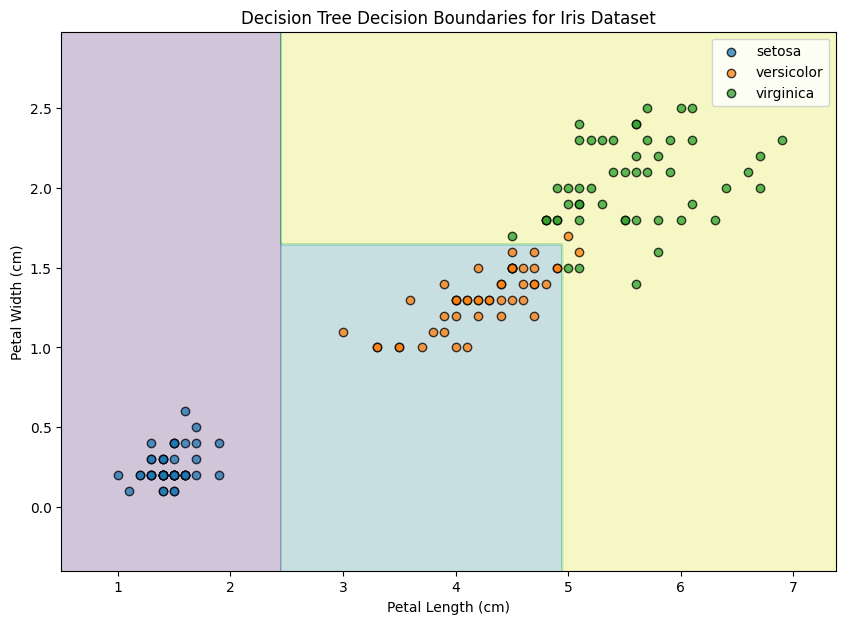

In [ ]:
X_two = X[:, [2, 3]]

X_train_two, X_test_two, y_train_two, y_test_two = train_test_split(
    X_two,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model_two = DecisionTreeClassifier(max_depth=3, random_state=42)
model_two.fit(X_train_two, y_train_two)

x_min, x_max = X_two[:, 0].min() - 0.5, X_two[:, 0].max() + 0.5
y_min, y_max = X_two[:, 1].min() - 0.5, X_two[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model_two.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.25)

for class_index, species_name in enumerate(iris.target_names):
    plt.scatter(
        X_two[y == class_index, 0],
        X_two[y == class_index, 1],
        label=species_name,
        edgecolor='black',
        alpha=0.75
    )

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Decision Tree Decision Boundaries for Iris Dataset')
plt.legend()
plt.show()


## Conclusion

The Decision Tree Classifier separates Iris Setosa easily because its petals are much smaller. Iris Versicolor and Iris Virginica are mainly separated using petal length and petal width. The tree is easy to interpret because every prediction can be traced through a sequence of decision rules.